# Инициализация

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer # type: ignore
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder # type: ignore
import warnings
from scipy import stats

In [40]:
data = pd.read_csv('cars.csv')

# Исследование исходного датасета

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  object 
 1   model_name         38531 non-null  object 
 2   transmission       38531 non-null  object 
 3   color              38531 non-null  object 
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  object 
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  object 
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  object 
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  object 
 13  drivetrain         38531 non-null  object 
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    385

In [42]:
data.columns

Index(['manufacturer_name', 'model_name', 'transmission', 'color',
       'odometer_value', 'year_produced', 'engine_fuel', 'engine_has_gas',
       'engine_type', 'engine_capacity', 'body_type', 'has_warranty', 'state',
       'drivetrain', 'price_usd', 'is_exchangeable', 'location_region',
       'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'duration_listed'],
      dtype='object')

In [43]:
data.head(20)

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
5,Subaru,Outback,automatic,silver,132449,2011,gasoline,False,gasoline,2.5,...,True,False,False,False,True,False,True,True,True,67
6,Subaru,Forester,automatic,black,318280,1998,gasoline,False,gasoline,2.5,...,True,False,False,True,True,False,False,True,True,307
7,Subaru,Legacy,automatic,silver,350000,2004,gasoline,False,gasoline,2.5,...,True,True,False,False,False,False,False,False,True,73
8,Subaru,Outback,automatic,grey,179000,2010,gasoline,False,gasoline,2.5,...,True,True,True,True,True,True,True,True,True,87
9,Subaru,Forester,automatic,silver,571317,1999,gasoline,False,gasoline,2.5,...,True,True,False,False,True,False,False,False,True,43


- **manufacturer_name**, **model_name**, **color**  - нельзя заменить на one hot,скорее всего от них избавимсмся если нет , корреляции на цену
- **engine_type** - поскольку он очень схож с **engine_fuel** но описывает меньше условий, его просто удалисм
- **state** можем заменить на ранговые (0, 1, 2)
- **transmission**,  - можно заменить на бинарный признак (автомат - 1, механика - 0)
- **drivetrain** - можно замеить на ранговые (передний - 0, задний - 1, полный - 2)
-  **location_region**, **body_type**, **engine_fuel** - применим one-hot

In [44]:
data = data.drop(columns=['engine_type'])

In [45]:
ordinal_encode_f1 = OrdinalEncoder(categories=[['emergency', 'owned', 'new']])
ordinal_encode_f2 = OrdinalEncoder(categories=[['front', 'rear', 'all']])
ordinal_encode_f3 = OrdinalEncoder(categories=[['mechanical','automatic']])


data["transmission"] = ordinal_encode_f3.fit_transform(data[["transmission"]])
data["state"] = ordinal_encode_f1.fit_transform(data[["state"]])
data["drivetrain"] = ordinal_encode_f2.fit_transform(data[["drivetrain"]])

In [46]:
dummies = pd.get_dummies(data[['location_region', 'body_type', 'engine_fuel']], 
                         prefix=['loc', 'body', 'fuel'],  # Для удобства
                         drop_first=False)
# Удаляем исходные категориальные столбцы
data = data.drop(columns=['location_region', 'body_type', 'engine_fuel'])

# Объединяем дамми-переменные с оставшимися данными
data = pd.concat([data, dummies], axis=1)

In [47]:
data.head(20)

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,Subaru,Outback,1.0,silver,190000,2010,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False
1,Subaru,Outback,1.0,blue,290000,2002,False,3.0,False,1.0,...,False,False,True,False,False,False,False,True,False,False
2,Subaru,Forester,1.0,red,402000,2001,False,2.5,False,1.0,...,False,True,False,False,False,False,False,True,False,False
3,Subaru,Impreza,0.0,blue,10000,1999,False,3.0,False,1.0,...,True,False,False,False,False,False,False,True,False,False
4,Subaru,Legacy,1.0,black,280000,2001,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False
5,Subaru,Outback,1.0,silver,132449,2011,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False
6,Subaru,Forester,1.0,black,318280,1998,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False
7,Subaru,Legacy,1.0,silver,350000,2004,False,2.5,False,1.0,...,True,False,False,False,False,False,False,True,False,False
8,Subaru,Outback,1.0,grey,179000,2010,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False
9,Subaru,Forester,1.0,silver,571317,1999,False,2.5,False,1.0,...,False,False,True,False,False,False,False,True,False,False


In [48]:
int(data.duplicated().sum())

40

In [49]:
data = data.drop_duplicates(ignore_index=True)
int(data.duplicated().sum()), data.shape[0]

(0, 38491)

In [50]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

engine_capacity         0.02598
manufacturer_name       0.00000
body_minivan            0.00000
loc_Гомельская обл.     0.00000
loc_Гродненская обл.    0.00000
loc_Минская обл.        0.00000
loc_Могилевская обл.    0.00000
body_cabriolet          0.00000
body_coupe              0.00000
body_hatchback          0.00000
body_liftback           0.00000
body_limousine          0.00000
body_minibus            0.00000
body_pickup             0.00000
loc_Брестская обл.      0.00000
body_sedan              0.00000
body_suv                0.00000
body_universal          0.00000
body_van                0.00000
fuel_diesel             0.00000
fuel_electric           0.00000
fuel_gas                0.00000
fuel_gasoline           0.00000
fuel_hybrid-diesel      0.00000
loc_Витебская обл.      0.00000
duration_listed         0.00000
model_name              0.00000
feature_9               0.00000
transmission            0.00000
color                   0.00000
odometer_value          0.00000
year_pro

In [51]:
mode_value = data['engine_capacity'].mode()[0]
data = data.fillna({'engine_capacity': mode_value})
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

manufacturer_name       0.0
body_minibus            0.0
loc_Витебская обл.      0.0
loc_Гомельская обл.     0.0
loc_Гродненская обл.    0.0
loc_Минская обл.        0.0
loc_Могилевская обл.    0.0
body_cabriolet          0.0
body_coupe              0.0
body_hatchback          0.0
body_liftback           0.0
body_limousine          0.0
body_minivan            0.0
model_name              0.0
body_pickup             0.0
body_sedan              0.0
body_suv                0.0
body_universal          0.0
body_van                0.0
fuel_diesel             0.0
fuel_electric           0.0
fuel_gas                0.0
fuel_gasoline           0.0
fuel_hybrid-diesel      0.0
loc_Брестская обл.      0.0
duration_listed         0.0
feature_9               0.0
feature_8               0.0
transmission            0.0
color                   0.0
odometer_value          0.0
year_produced           0.0
engine_has_gas          0.0
engine_capacity         0.0
has_warranty            0.0
state               

In [52]:
data['manufacturer_name'].unique()

array(['Subaru', 'LADA', 'Dodge', 'УАЗ', 'Kia', 'Opel', 'Москвич',
       'Alfa Romeo', 'Acura', 'Dacia', 'Lexus', 'Mitsubishi', 'Lancia',
       'Citroen', 'Mini', 'Jaguar', 'Porsche', 'SsangYong', 'Daewoo',
       'Geely', 'ВАЗ', 'Fiat', 'Ford', 'Renault', 'Seat', 'Rover',
       'Volkswagen', 'Lifan', 'Jeep', 'Cadillac', 'Audi', 'ЗАЗ', 'Toyota',
       'ГАЗ', 'Volvo', 'Chevrolet', 'Great Wall', 'Buick', 'Pontiac',
       'Lincoln', 'Hyundai', 'Nissan', 'Suzuki', 'BMW', 'Mazda',
       'Land Rover', 'Iveco', 'Skoda', 'Saab', 'Infiniti', 'Chery',
       'Honda', 'Mercedes-Benz', 'Peugeot', 'Chrysler'], dtype=object)

# Коррекция типов данных

In [53]:
df = data[['manufacturer_name', 'year_produced', 'price_usd']]
df

,manufacturer_name,year_produced,price_usd
0,Subaru,2010,10900.00
1,Subaru,2002,5000.00
2,Subaru,2001,2800.00
3,Subaru,1999,9999.00
4,Subaru,2001,2134.11
...,...,...,...
38486,Chrysler,2000,2750.00
38487,Chrysler,2004,4800.00
38488,Chrysler,2000,4300.00
38489,Chrysler,2001,4000.00


In [54]:
df = df[df['year_produced'] > 2010].reset_index(drop=True)
df

,manufacturer_name,year_produced,price_usd
0,Subaru,2011,14700.0
1,Subaru,2011,8600.0
2,Subaru,2014,12700.0
3,Subaru,2013,16500.0
4,Subaru,2011,14950.0
...,...,...,...
7199,Chrysler,2016,21800.0
7200,Chrysler,2012,19999.0
7201,Chrysler,2016,10350.0
7202,Chrysler,2015,26500.0


In [55]:
model = df['manufacturer_name'].unique()
model

array(['Subaru', 'LADA', 'Dodge', 'УАЗ', 'Kia', 'Opel', 'Alfa Romeo',
       'Acura', 'Dacia', 'Lexus', 'Mitsubishi', 'Citroen', 'Mini',
       'Jaguar', 'Porsche', 'SsangYong', 'Daewoo', 'Geely', 'ВАЗ', 'Fiat',
       'Ford', 'Renault', 'Seat', 'Volkswagen', 'Lifan', 'Jeep',
       'Cadillac', 'Audi', 'ЗАЗ', 'Toyota', 'ГАЗ', 'Volvo', 'Chevrolet',
       'Great Wall', 'Buick', 'Lincoln', 'Hyundai', 'Nissan', 'Suzuki',
       'BMW', 'Mazda', 'Land Rover', 'Iveco', 'Skoda', 'Saab', 'Infiniti',
       'Chery', 'Honda', 'Mercedes-Benz', 'Peugeot', 'Chrysler'],
      dtype=object)

Потеряли данные марки, в исходном датасете просто добавим их в бюджетный сегмент

In [56]:
models = df['manufacturer_name'].unique()
diff = set(data['manufacturer_name'].unique()) - set(models)
for model in diff:
    print(f'{model}: {data[data["manufacturer_name"] == model].shape[0]}')

Pontiac: 42
Москвич: 55
Lancia: 92
Rover: 235


In [57]:
dictonary = dict()
for model in models:
    mod = df[df["manufacturer_name"] == model]
    mean = mod["price_usd"].sum()/mod.shape[0]
    dictonary[model] = float(round(mean, 2))
    
dictonary

{'Subaru': 16465.65,
 'LADA': 8626.81,
 'Dodge': 18770.75,
 'УАЗ': 8703.58,
 'Kia': 12858.97,
 'Opel': 10857.2,
 'Alfa Romeo': 9000.0,
 'Acura': 21792.13,
 'Dacia': 8794.54,
 'Lexus': 26756.15,
 'Mitsubishi': 15395.68,
 'Citroen': 9895.61,
 'Mini': 18513.8,
 'Jaguar': 29601.3,
 'Porsche': 32294.0,
 'SsangYong': 11145.75,
 'Daewoo': 2862.42,
 'Geely': 9189.12,
 'ВАЗ': 6725.64,
 'Fiat': 12282.87,
 'Ford': 12851.92,
 'Renault': 10292.24,
 'Seat': 10459.44,
 'Volkswagen': 13571.18,
 'Lifan': 8548.78,
 'Jeep': 21702.96,
 'Cadillac': 19370.71,
 'Audi': 18930.6,
 'ЗАЗ': 3268.48,
 'Toyota': 18331.84,
 'ГАЗ': 14429.33,
 'Volvo': 16779.55,
 'Chevrolet': 10746.02,
 'Great Wall': 9413.2,
 'Buick': 12875.27,
 'Lincoln': 23092.86,
 'Hyundai': 13242.53,
 'Nissan': 13761.21,
 'Suzuki': 10779.34,
 'BMW': 23556.9,
 'Mazda': 15430.47,
 'Land Rover': 27922.41,
 'Iveco': 22000.55,
 'Skoda': 18528.89,
 'Saab': 17500.0,
 'Infiniti': 22534.4,
 'Chery': 6602.72,
 'Honda': 16167.82,
 'Mercedes-Benz': 25009.33,


In [58]:
prices = list(dictonary.values())
q25 = np.percentile(prices, 25)
q75 = np.percentile(prices, 75)

In [59]:
categorized = {}
for brand, price in dictonary.items():
    if price <= q25:
        categorized[brand] = 0 #Бюджет
    elif price >= q75:
        categorized[brand] = 2 #Средний
    else:
        categorized[brand] = 1 #Премиум

print(f"Пороги: бюджет до {round(q25, 2)}$, премиум от {round(q75, 2)}$")
for i in diff:
    categorized[i] = 0
print(categorized)

Пороги: бюджет до 10093.92$, премиум от 19150.66$
{'Subaru': 1, 'LADA': 0, 'Dodge': 1, 'УАЗ': 0, 'Kia': 1, 'Opel': 1, 'Alfa Romeo': 0, 'Acura': 2, 'Dacia': 0, 'Lexus': 2, 'Mitsubishi': 1, 'Citroen': 0, 'Mini': 1, 'Jaguar': 2, 'Porsche': 2, 'SsangYong': 1, 'Daewoo': 0, 'Geely': 0, 'ВАЗ': 0, 'Fiat': 1, 'Ford': 1, 'Renault': 1, 'Seat': 1, 'Volkswagen': 1, 'Lifan': 0, 'Jeep': 2, 'Cadillac': 2, 'Audi': 1, 'ЗАЗ': 0, 'Toyota': 1, 'ГАЗ': 1, 'Volvo': 1, 'Chevrolet': 1, 'Great Wall': 0, 'Buick': 1, 'Lincoln': 2, 'Hyundai': 1, 'Nissan': 1, 'Suzuki': 1, 'BMW': 2, 'Mazda': 1, 'Land Rover': 2, 'Iveco': 2, 'Skoda': 1, 'Saab': 1, 'Infiniti': 2, 'Chery': 0, 'Honda': 1, 'Mercedes-Benz': 2, 'Peugeot': 0, 'Chrysler': 2, 'Pontiac': 0, 'Москвич': 0, 'Lancia': 0, 'Rover': 0}


In [60]:
data['manufacturer_name'] = data['manufacturer_name'].map(categorized)
data = data.drop(columns='model_name') 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  float64
 2   color                 38491 non-null  object 
 3   odometer_value        38491 non-null  int64  
 4   year_produced         38491 non-null  int64  
 5   engine_has_gas        38491 non-null  bool   
 6   engine_capacity       38491 non-null  float64
 7   has_warranty          38491 non-null  bool   
 8   state                 38491 non-null  float64
 9   drivetrain            38491 non-null  float64
 10  price_usd             38491 non-null  float64
 11  is_exchangeable       38491 non-null  bool   
 12  number_of_photos      38491 non-null  int64  
 13  up_counter            38491 non-null  int64  
 14  feature_0             38491 non-null  bool   
 15  feature_1          

In [61]:
data = data.drop(columns='color')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  float64
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  bool   
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  bool   
 7   state                 38491 non-null  float64
 8   drivetrain            38491 non-null  float64
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  bool   
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  bool   
 14  feature_1             38491 non-null  bool   
 15  feature_2          

In [62]:
bool_columns = data.select_dtypes(include='bool').columns
data[bool_columns] = data[bool_columns].astype(int)

In [63]:
col = ['transmission', 'state', 'drivetrain']
for c in col:
    data[c] = data[c].astype(int)

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  int32  
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  int32  
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  int32  
 7   state                 38491 non-null  int32  
 8   drivetrain            38491 non-null  int32  
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  int32  
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  int32  
 14  feature_1             38491 non-null  int32  
 15  feature_2          

# EDA

In [65]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
manufacturer_name,38491.0,1.025590,0.549730,0.0,1.0,1.0,1.0,2.0
transmission,38491.0,0.334935,0.471974,0.0,0.0,0.0,1.0,1.0
odometer_value,38491.0,249058.310514,135918.326857,0.0,158000.0,250000.0,325000.0,1000000.0
year_produced,38491.0,2002.930815,8.056156,1942.0,1998.0,2003.0,2009.0,2019.0
engine_has_gas,38491.0,0.034995,0.183770,0.0,0.0,0.0,0.0,1.0
engine_capacity,38491.0,2.055524,0.671300,0.2,1.6,2.0,2.3,8.0
has_warranty,38491.0,0.010834,0.103521,0.0,0.0,0.0,0.0,1.0
state,38491.0,1.000935,0.141987,0.0,1.0,1.0,1.0,2.0
drivetrain,38491.0,0.419994,0.723477,0.0,0.0,0.0,1.0,2.0
price_usd,38491.0,6632.809227,6424.033741,1.0,2100.0,4800.0,8950.0,50000.0


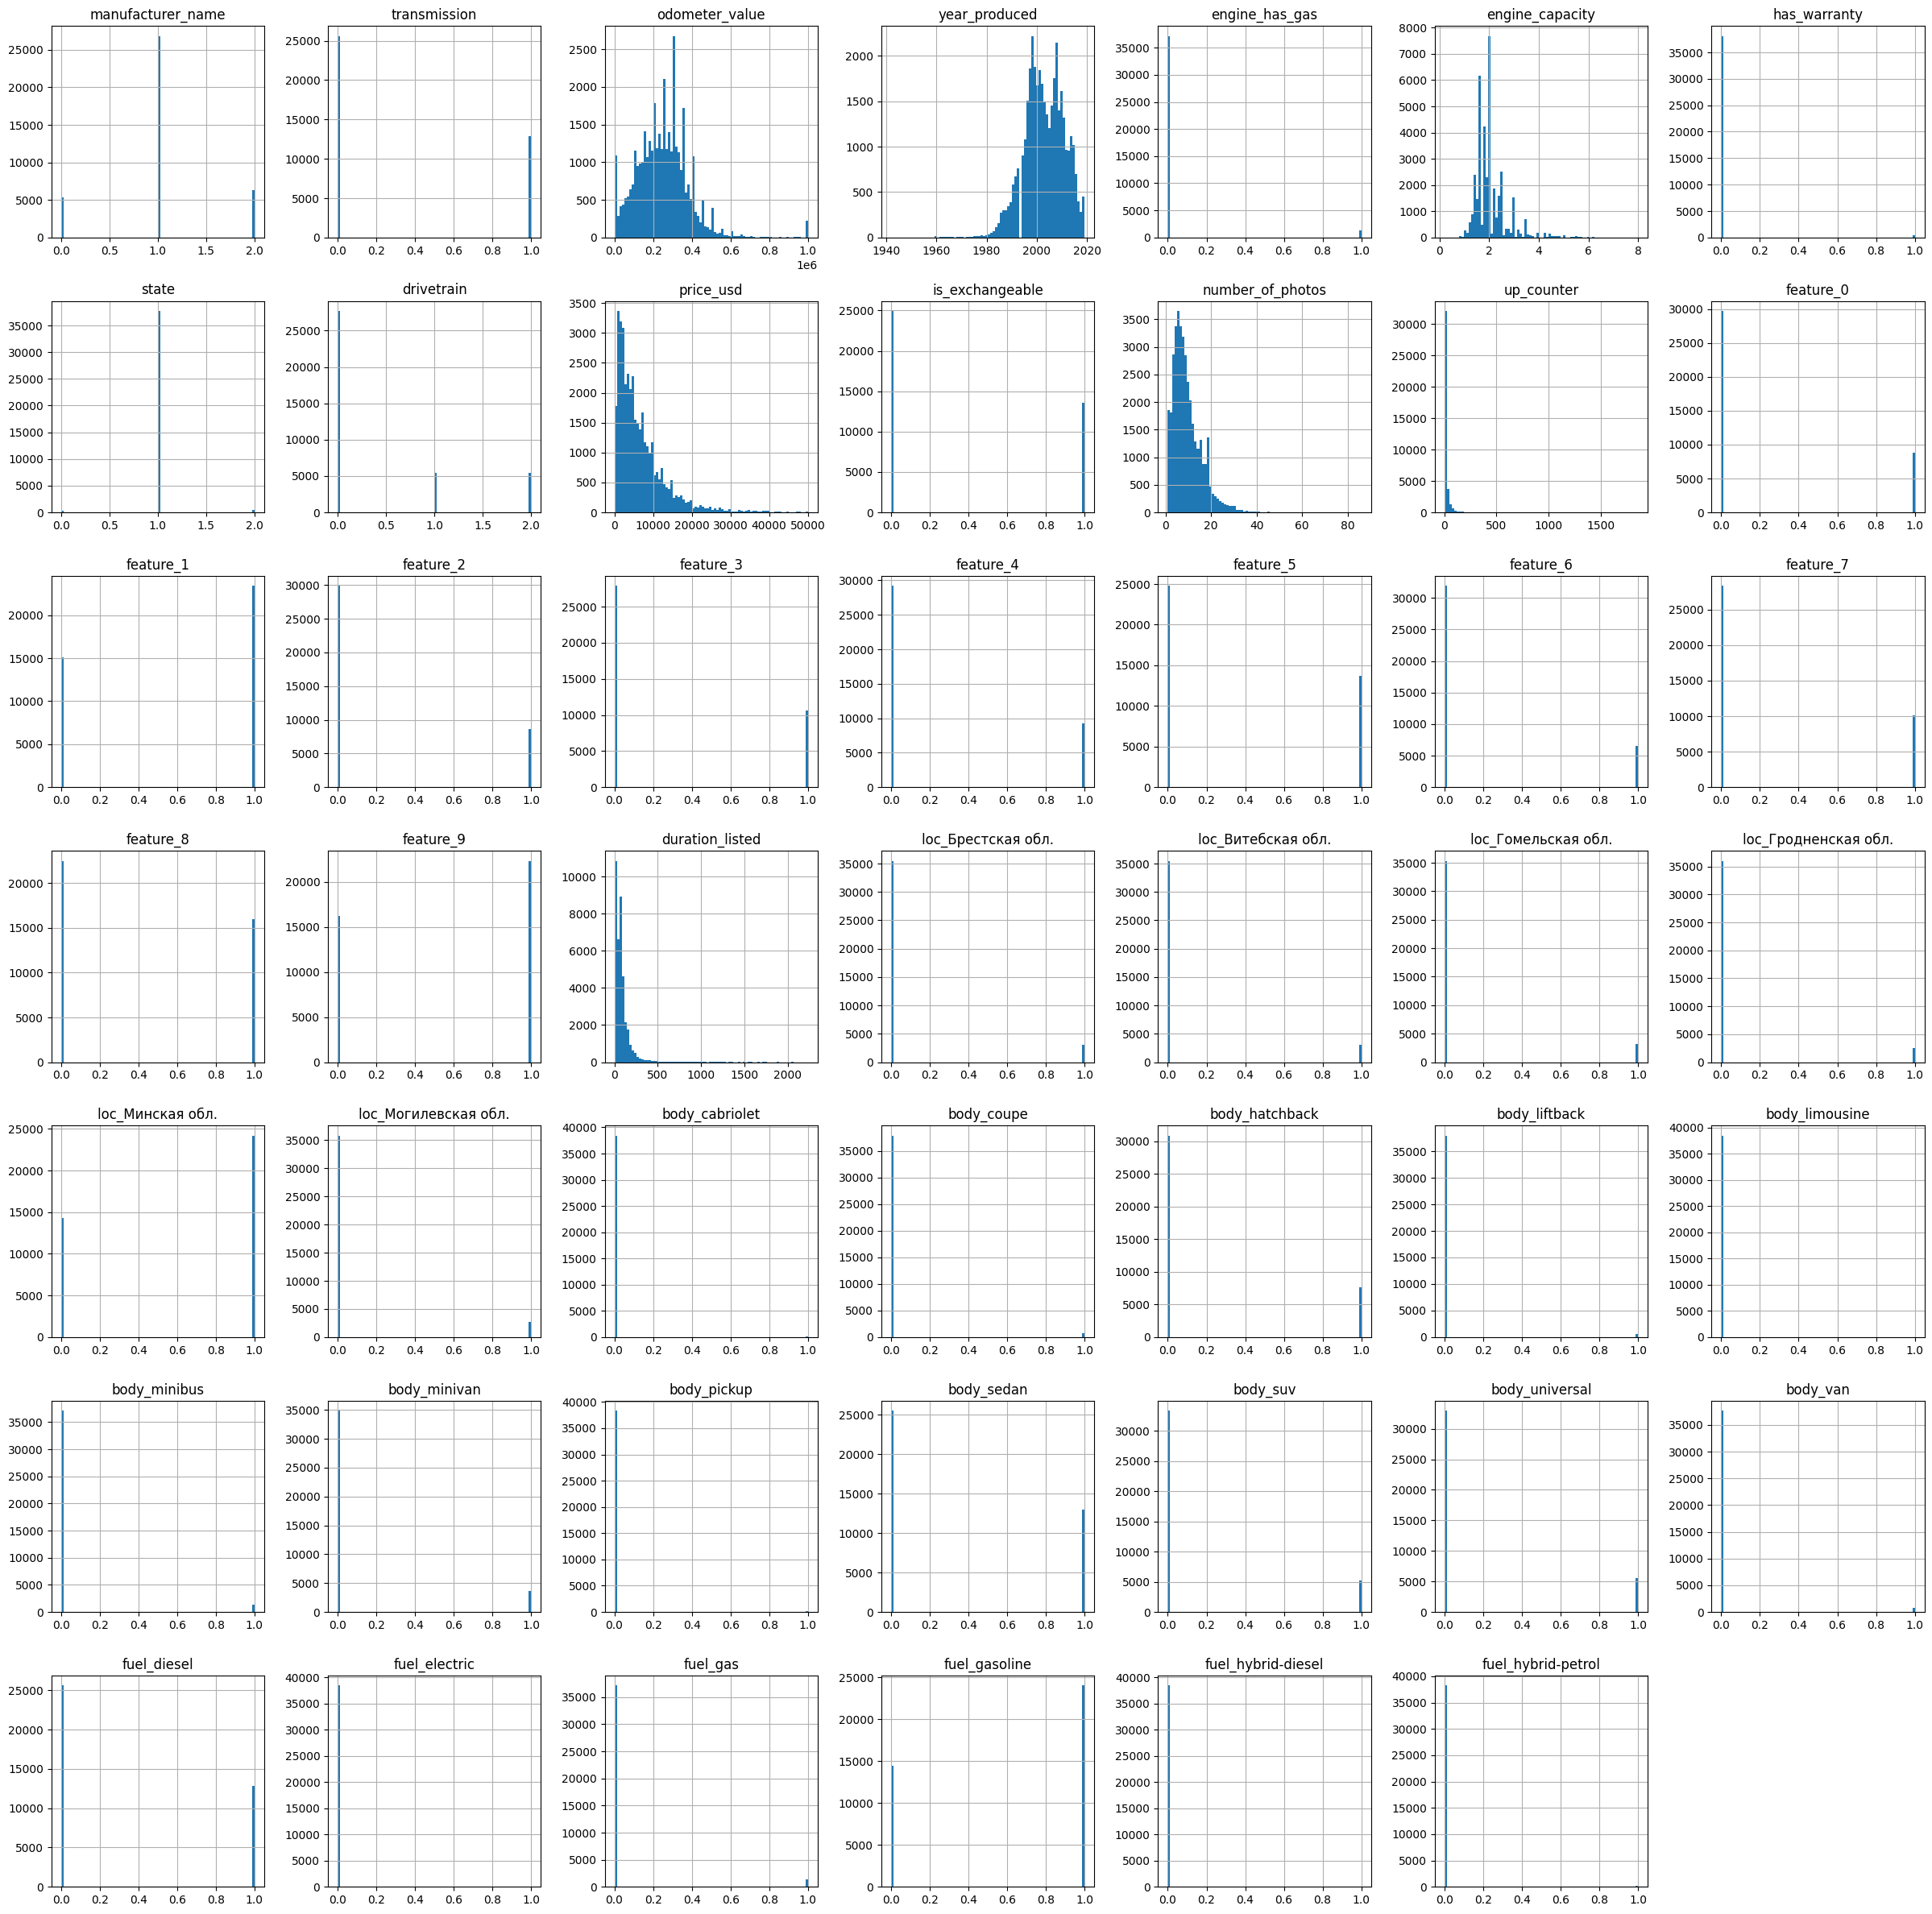

In [66]:
data.hist(figsize=(30, 30), bins=80)
plt.show()

array([[<Axes: title={'center': 'price_usd'}>]], dtype=object)

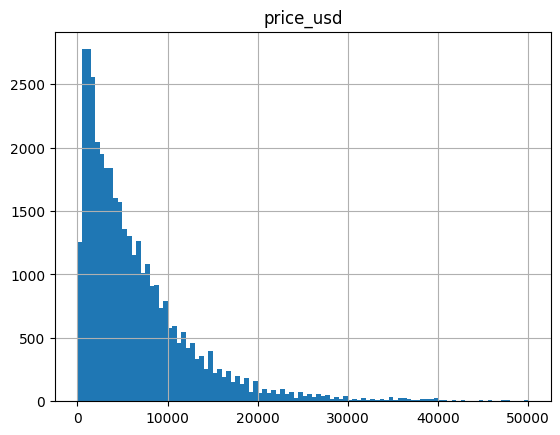

In [67]:
data.hist(column='price_usd', bins=100)

Много дешевых машин и мало дорогих

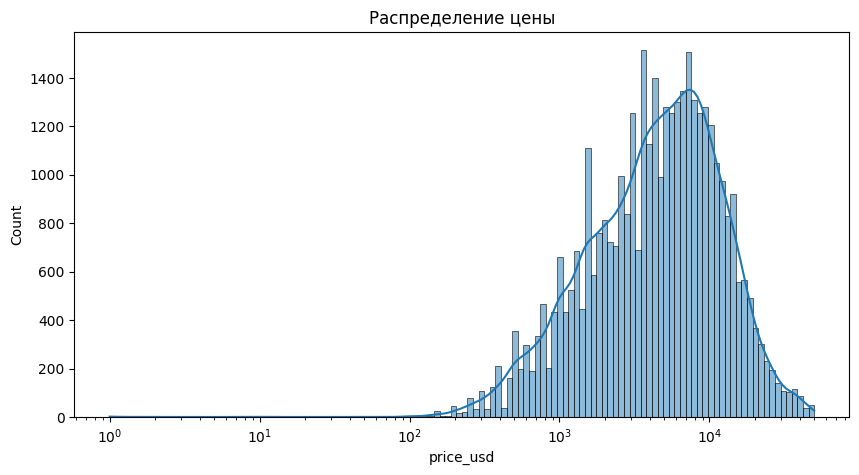

In [68]:
plt.figure(figsize=(10, 5))
# Логарифмируем масштаб оси х
sns.histplot(data['price_usd'], kde=True, log_scale=True)
plt.title('Распределение цены')
plt.show()

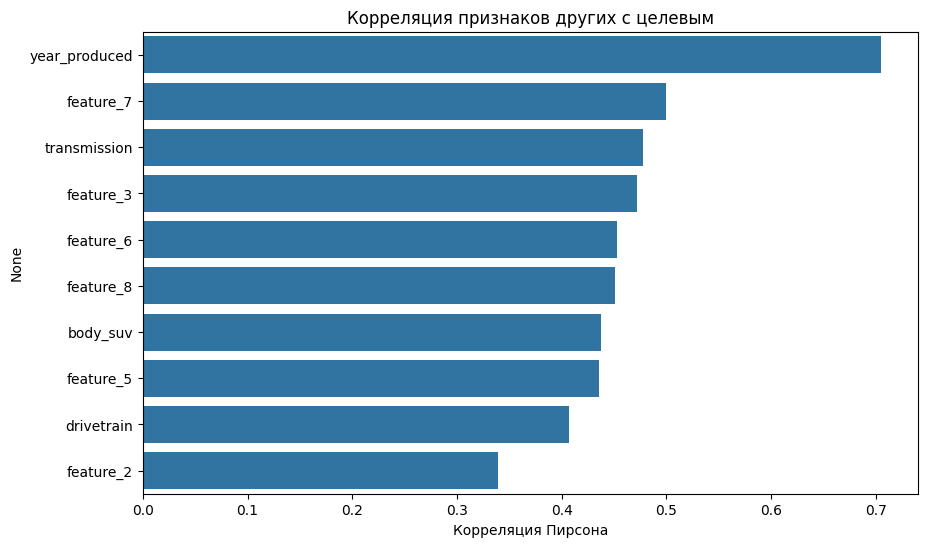

In [69]:
corr_with_price = data.corr(numeric_only=True)['price_usd'].sort_values(ascending=False)

top_features = corr_with_price.drop('price_usd').head(10).index
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_price[top_features].values, y=top_features)
plt.title('Корреляция признаков других с целевым')
plt.xlabel('Корреляция Пирсона')
plt.show()

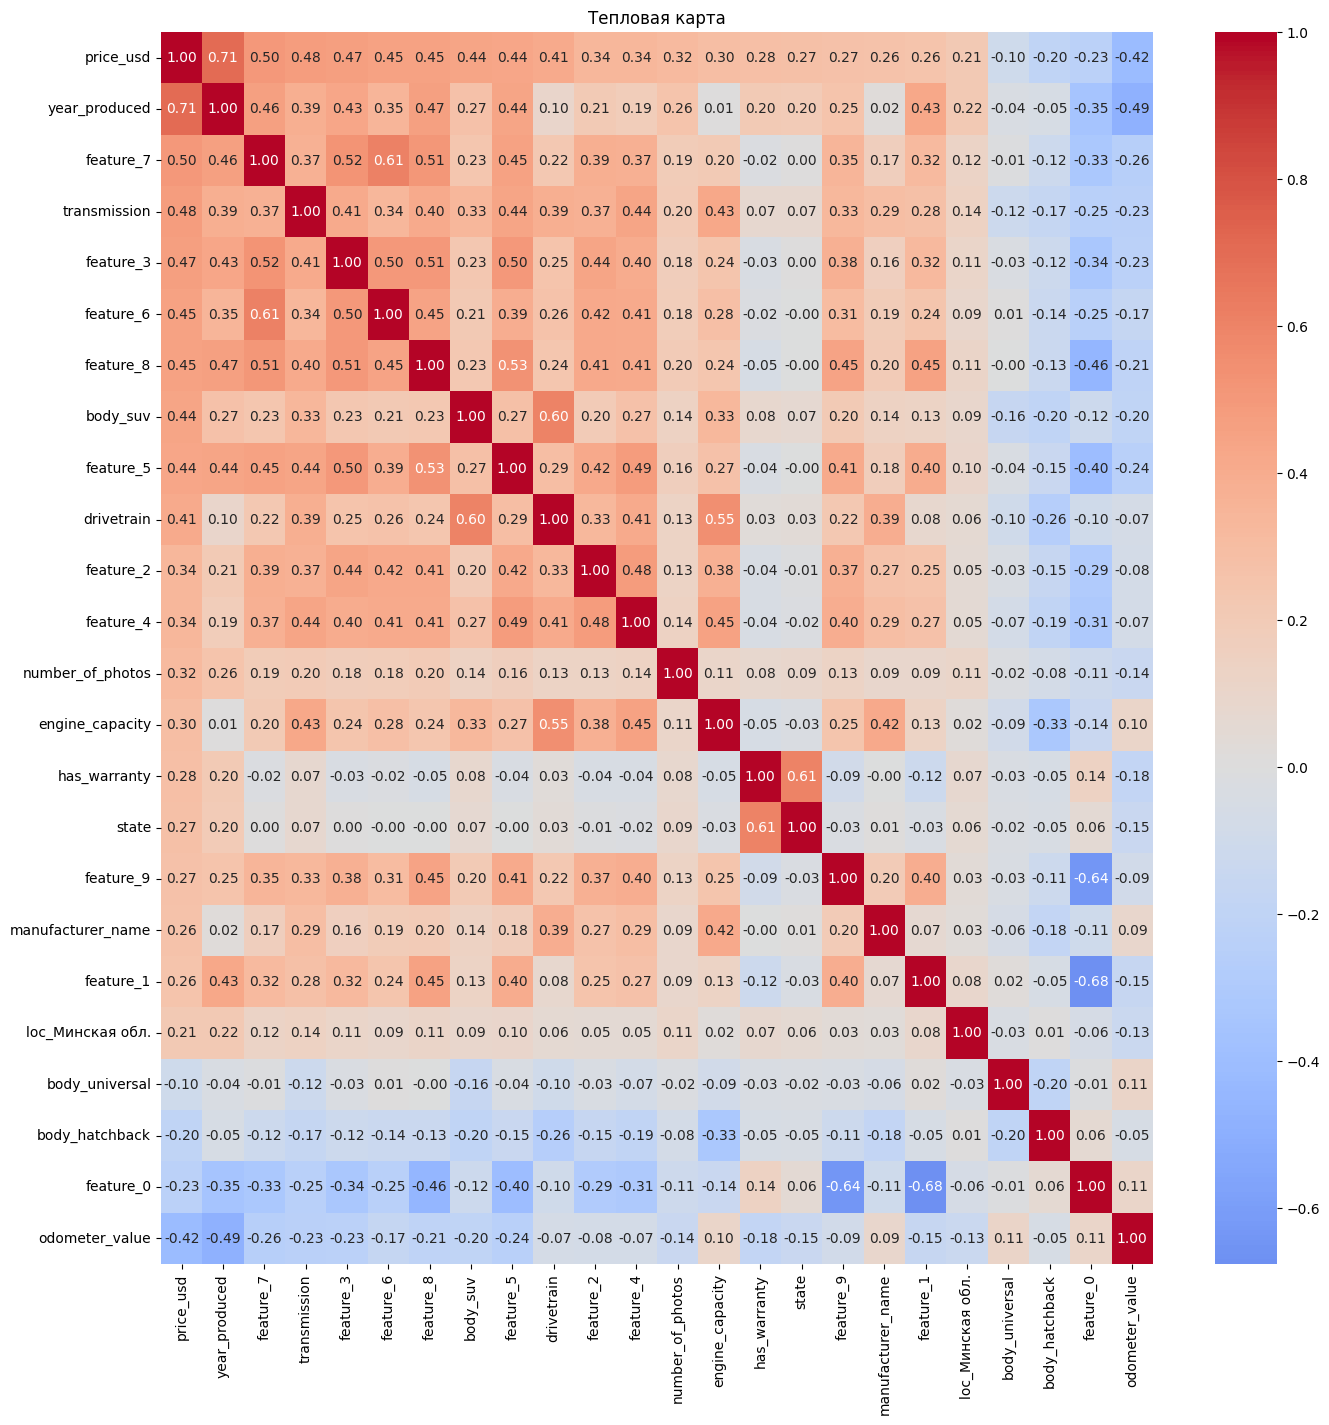

In [70]:
corr_with_price = data.corr(numeric_only=True)['price_usd'].sort_values(ascending=False)
high_corr_features = corr_with_price[abs(corr_with_price) > 0.1].index
plt.figure(figsize=(16,16))
sns.heatmap(data[high_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Тепловая карта')
plt.show()

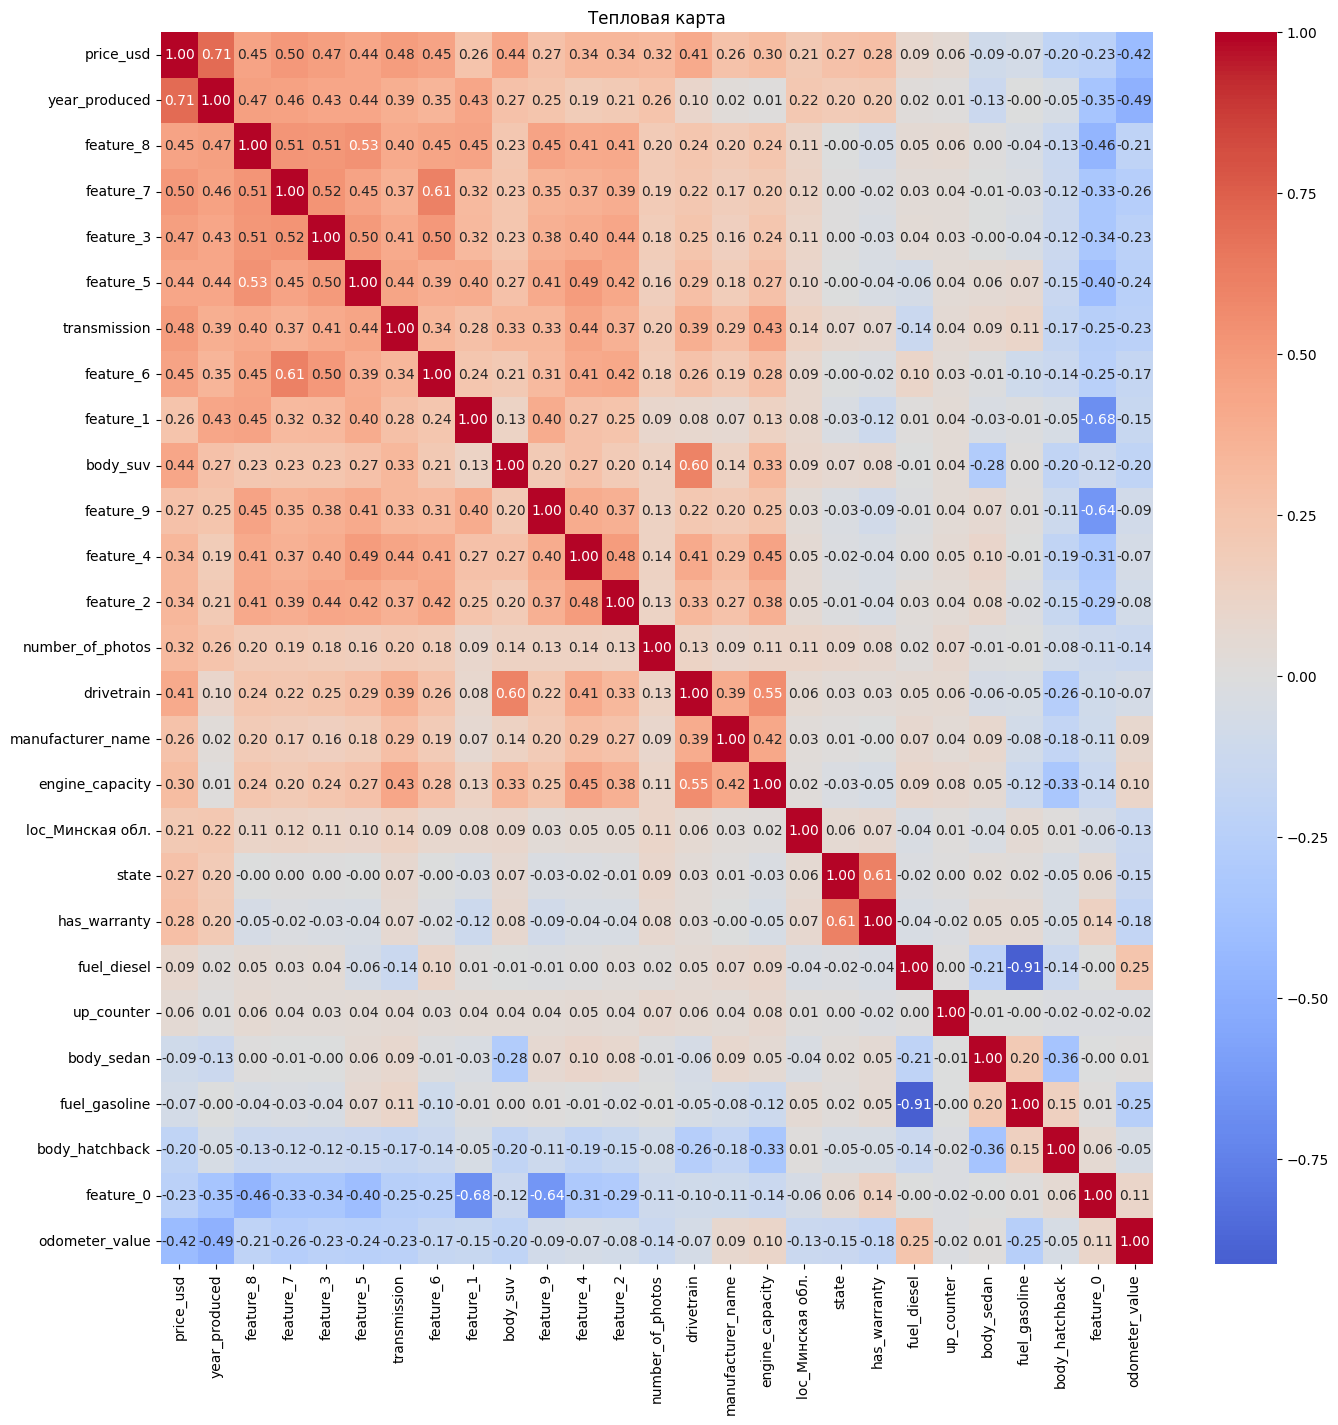

In [71]:
corr_with_price = data.corr(numeric_only=True, method='spearman')['price_usd'].sort_values(ascending=False)
high_corr_features = corr_with_price[abs(corr_with_price) > 0.1].index
plt.figure(figsize=(16,16))
sns.heatmap(data[high_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Тепловая карта')
plt.show()

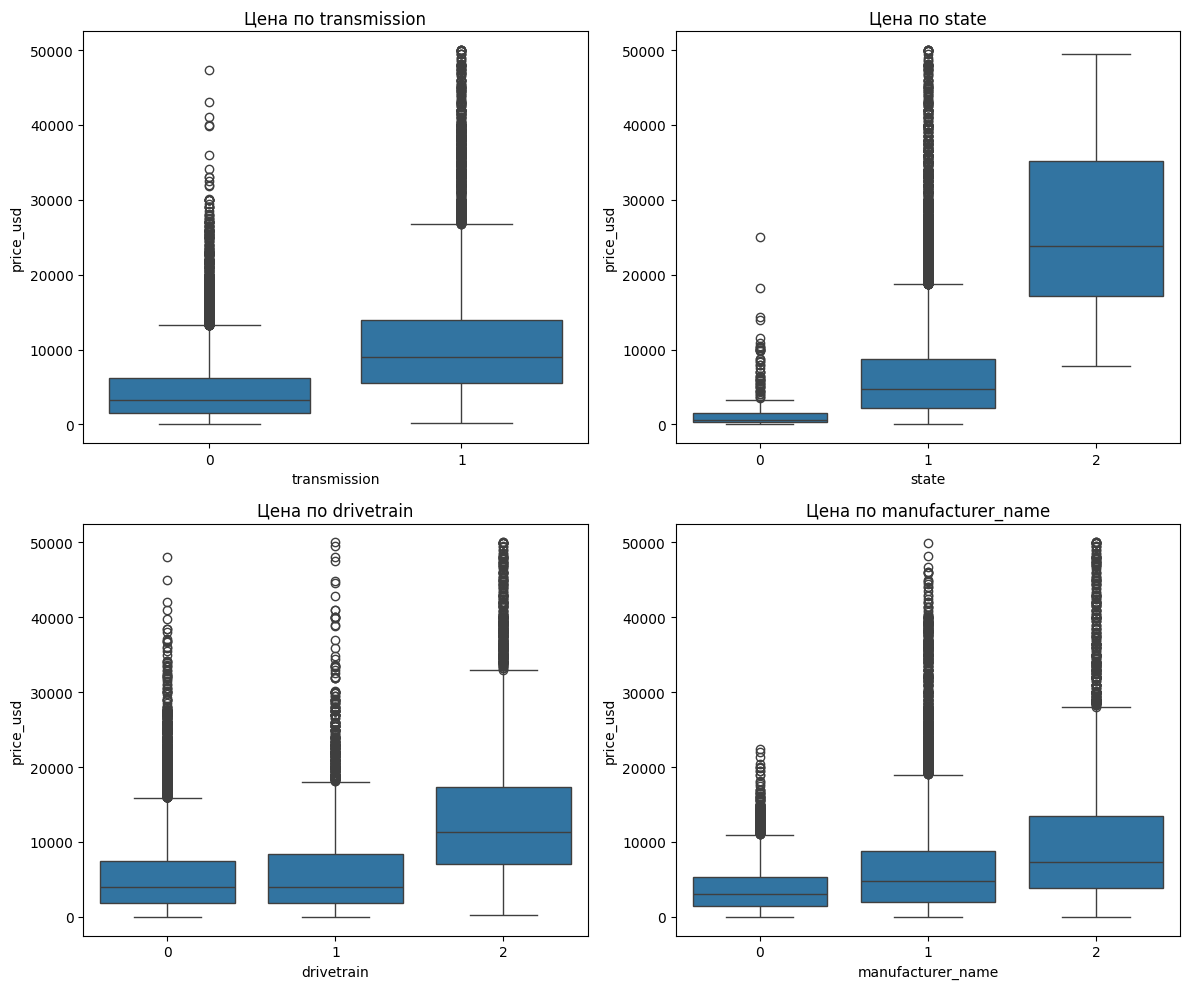

In [72]:
ordinal_cols = ['transmission', 'state', 'drivetrain', 'manufacturer_name']
fig, axes = plt.subplots(2,2, figsize=(12,10))
for ax, col in zip(axes.ravel(), ordinal_cols):
    sns.boxplot(data=data, x=col, y='price_usd', ax=ax)
    ax.set_title(f'Цена по {col}')
plt.tight_layout()
plt.show()

In [73]:
data.head(20)

,manufacturer_name,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,drivetrain,price_usd,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,1,1,190000,2010,0,2.5,0,1,2,10900.00,...,0,0,1,0,0,0,0,1,0,0
1,1,1,290000,2002,0,3.0,0,1,2,5000.00,...,0,0,1,0,0,0,0,1,0,0
2,1,1,402000,2001,0,2.5,0,1,2,2800.00,...,0,1,0,0,0,0,0,1,0,0
3,1,0,10000,1999,0,3.0,0,1,2,9999.00,...,1,0,0,0,0,0,0,1,0,0
4,1,1,280000,2001,0,2.5,0,1,2,2134.11,...,0,0,1,0,0,0,0,1,0,0
5,1,1,132449,2011,0,2.5,0,1,2,14700.00,...,0,0,1,0,0,0,0,1,0,0
6,1,1,318280,1998,0,2.5,0,1,2,3000.00,...,0,0,1,0,0,0,0,1,0,0
7,1,1,350000,2004,0,2.5,0,1,2,4500.00,...,1,0,0,0,0,0,0,1,0,0
8,1,1,179000,2010,0,2.5,0,1,2,12900.00,...,0,0,1,0,0,0,0,1,0,0
9,1,1,571317,1999,0,2.5,0,1,2,4200.00,...,0,0,1,0,0,0,0,1,0,0


In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  int32  
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  int32  
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  int32  
 7   state                 38491 non-null  int32  
 8   drivetrain            38491 non-null  int32  
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  int32  
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  int32  
 14  feature_1             38491 non-null  int32  
 15  feature_2          

In [75]:
num_cols_for_outliers = ['odometer_value', 'year_produced', 'engine_capacity', 
                         'number_of_photos', 'up_counter', 'duration_listed']

outliers_summary = {}
for col in num_cols_for_outliers:
    z = np.abs(stats.zscore(data[col]))
    outliers = np.sum(z > 3)  # считаем выбросами значения с |z|>3
    outliers_summary[col] = outliers

outliers_df = pd.DataFrame.from_dict(outliers_summary, orient='index', columns=['количество выбросов'])
outliers_df['доля (%)'] = outliers_df['количество выбросов'] / len(data) * 100
outliers_df.sort_values('доля (%)', ascending=False)

,количество выбросов,доля (%)
engine_capacity,858,2.229093
number_of_photos,640,1.662726
duration_listed,601,1.561404
up_counter,465,1.208075
odometer_value,375,0.974254
year_produced,166,0.431270


In [78]:
data.to_csv('cars_cleaned.csv', index=False)

Заключение

В ходе выполненного анализа была проведена комплексная подготовка и исследование набора данных, содержащего информацию о подержанных автомобилях. Основные этапы работы включали очистку, преобразование признаков и глубокий разведочный анализ, что позволило сформировать качественную основу для последующего построения регрессионных моделей.
Основные результаты и выводы:

Качество данных:
Исходный набор данных оказался достаточно чистым – обнаружено лишь 40 дубликатов (удалены) и незначительное число пропусков (10 записей в поле engine_capacity), которые были заполнены модой. Это говорит о высоком качестве исходной информации.
Преобразование признаков: С целью повышения информативности модели и снижения размерности был проведён ряд преобразований:
Удалены избыточные (engine_type) и трудноинтерпретируемые (model_name, color) признаки.

Выполнено кодирование порядковых переменных (transmission, state, drivetrain).

Категориальные признаки (location_region, body_type, engine_fuel) преобразованы методом one-hot-кодирования.

Наиболее важным преобразованием стало создание нового признака manufacturer_name, отражающего ценовой сегмент бренда (бюджетный, средний, премиум). Это позволило учесть влияние марки на стоимость автомобиля в компактной и информативной форме.

Ключевые факторы, влияющие на цену: Корреляционный анализ выявил следующие закономерности:
Наибольшее положительное влияние на цену оказывает год выпуска автомобиля (year_produced, корреляция 0.71). Чем новее автомобиль, тем он дороже.

Ожидаемо сильное отрицательное влияние имеет пробег (odometer_value, корреляция -0.42). С увеличением пробега цена падает.

Ряд бинарных признаков (feature_*) и тип привода (drivetrain) также демонстрируют заметную корреляцию с ценой, что делает их потенциально важными предикторами.

Анализ бинарных признаков показал, что наличие гарантии (has_warranty) или принадлежность к типам кузова «внедорожник» (body_suv) значительно увеличивают среднюю стоимость автомобиля.

Проверка данных на выбросы: Выявлено небольшое количество выбросов (менее 2.5%) в таких признаках, как объём двигателя, количество фотографий и пробег. Это нормально для реальных данных и, вероятно, не потребует агрессивных методов обработки, однако при построении моделей следует учитывать их влияние.
итог
Проведённый EDA позволил получить глубокое понимание структуры данных и выявить ключевые факторы, определяющие стоимость подержанного автомобиля. Данные очищены, преобразованы и готовы к использованию в задачах регрессии.